__By: Paula Alvarez, Victor Camero, Daniela Lavanderas, Fernanda Vásquez__



In [1]:
using CSV, DataFrames, Plots, StatsBase,  Statistics

In [2]:
file_path = "../data/dataset_elpino.csv"
df = CSV.read(file_path, DataFrame; missingstring=["NA", "NULL", "-"], delim=';')
first(df, 3)

Row,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
,String,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,String?,Int64,String7,String
1,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada, en enfermedades clasificadas en otra parte",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] como causa de enfermedades clasificadas en otros capítulos,L89.9 - Úlcera de decúbito y area de presión no especificadas,"L08.9 - Infección local de la piel y del tejido subcutáneo, no especificada",B96.2 - Escherichia coli [E. coli] como causa de enfermedades clasificadas en otros capítulos,A41.5 - Sepsis por otros organnismos Gram negativos,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga, no especificada",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,"F19.2 - Trastornos mentales y del comportamiento debidos al uso de múltiples drogas y al uso de otras sustancias psicoactivas, síndrome de dependencia","F10.2 - Trastornos mentales y del comportamiento debidos al uso de alcohol, síndrome de dependencia","E46 - Desnutrición proteicocalórica, no especificada","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis

In [3]:
rows, columns = size(df)

(14561, 68)

# Busqueda de la edad maxima y minima

In [4]:
age = df[:, :"Edad en años"]
edad_maxima, edad_minima = maximum(age), minimum(age)

(121, 0)

In [5]:
indice_maximo = argmax(age)
println("El índice del valor máximo de edad es: ", indice_maximo)
age[2589]

El índice del valor máximo de edad es: 2589


121

In [6]:
println("La edad maxima es ", edad_maxima, " y la menor es ", edad_minima) # En ese cero, se debe tomar en cuenta que son recien nacidos(no olvidar)

La edad maxima es 121 y la menor es 0


__Segregación por edades:__

In [7]:
# Aqui guardo por segmentacion cada una de las edades en el dataset, en las listas
infante = [edad for edad in age if edad <= 5 && edad >= 0 ]
child = [edad for edad in age if edad <= 12 && edad >= 6 ]
adolecente = [edad for edad in age if edad <= 18 && edad >= 13]
joven_adulto = [edad for edad in age if edad <= 30 && edad >= 19]
adulto = [edad for edad in age if edad <= 60 && edad >= 31]
adulto_mayor = [edad for edad in age if edad >= 61]

3570-element Vector{Int64}:
 65
 61
 63
 66
 77
 69
 61
 69
 67
 77
 71
 67
 83
  ⋮
 95
 78
 75
 85
 73
 83
 82
 64
 73
 67
 80
 73

In [8]:
nombre_segmentacion = ["Infante", "Niños", "Adolecente", "Joven Adulto", "Adulto", "Adulto Mayor"]
# Agregacion de la cantidad de datos  por la segmentacion de edad
cantidad_por_edad = []
push!(cantidad_por_edad, length(infante))
push!(cantidad_por_edad, length(child))
push!(cantidad_por_edad, length(adolecente))
push!(cantidad_por_edad, length(joven_adulto))
push!(cantidad_por_edad, length(adulto))
push!(cantidad_por_edad, length(adulto_mayor))

6-element Vector{Any}:
 2000
  188
  429
 3238
 5136
 3570

In [9]:
calcular_porcentaje(x, row) = round(x/row * 100, digits=2)
porcentate_cantidad_por_edad = calcular_porcentaje.(cantidad_por_edad, rows)
contador = 1
while length(nombre_segmentacion) >= contador
    println("$(nombre_segmentacion[contador]) => $(porcentate_cantidad_por_edad[contador])%") # me quedo epico este ciclo 
    contador += 1
end

Infante => 13.74%
Niños => 1.29%
Adolecente => 2.95%
Joven Adulto => 22.24%
Adulto => 35.27%
Adulto Mayor => 24.52%


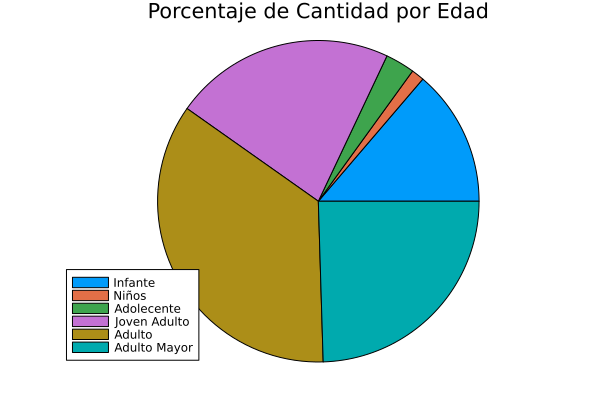

In [10]:
pie(nombre_segmentacion, 
    porcentate_cantidad_por_edad, 
    title="Porcentaje de Cantidad por Edad", 
    autopct = :pct)

# GRD mas comunes por segmento de edades

In [15]:
# Definimos los segmentos como un Diccionario de Tuplas
segmentos = Dict(
    "Infante" => (0, 5),
    "Niños" => (6, 12),
    "Adolecente" => (13, 18),
    "Joven Adulto" => (19, 30),
    "Adulto" => (31, 60),
    "Adulto Mayor" => (61, 150)  # Asumiendo una edad máxima razonable
)

Dict{String, Tuple{Int64, Int64}} with 6 entries:
  "Adolecente"   => (13, 18)
  "Infante"      => (0, 5)
  "Adulto Mayor" => (61, 150)
  "Niños"        => (6, 12)
  "Adulto"       => (31, 60)
  "Joven Adulto" => (19, 30)

In [16]:
function top_grd_por_segmento(df, segmentos)
    resultados = Dict{String, Any}()
    
    for (nombre, (min_edad, max_edad)) in segmentos
        subdf = filter(row -> min_edad <= row[:"Edad en años"] <= max_edad, df)
        
        if nrow(subdf) > 0
            # Especificamos explícitamente el paquete
            conteos = StatsBase.countmap(subdf.GRD)
            top5 = sort(collect(conteos), by = x -> x[2], rev = true)[1:min(5, end)]
            resultados[nombre] = top5
        else
            resultados[nombre] = "Sin casos registrados"
        end
    end
    
    return resultados
end

top_grd_por_segmento (generic function with 1 method)

In [13]:
# Uso del código (ejemplo)
resultados = top_grd_por_segmento(df, segmentos)

# Para visualizar los resultados de forma ordenada
for (segmento, datos) in resultados
    println("\n=== $segmento ===")
    if isa(datos, Vector)
        for (i, (grd, conteo)) in enumerate(datos)
            println("$i. $grd: $conteo casos")
        end
    else
        println(datos)
    end
end


=== Adolecente ===
1. 146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO: 28 casos
2. 061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE: 24 casos
3. 146131 - PH PARTO VAGINAL: 21 casos
4. 214121 - MH ENVENENAMIENTO Y EFECTO TÓXICO DE DROGAS: 17 casos
5. 146101 - PH CESÁREA: 16 casos

=== Infante ===
1. 158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR: 389 casos
2. 044163 - MH NEUMONÍA SIMPLE Y TOS FERINA W/MCC: 137 casos
3. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 133 casos
4. 044213 - MH OTROS SIGNOS, SÍNTOMAS Y DIAGNÓSTICOS DE APARATO RESPIRATORIO W/MCC: 113 casos
5. 014241 - MH TRAUMATISMO CEFÁLICO: 83 casos

=== Adulto Mayor ===
1. 044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC: 200 casos
2. 054123 - MH INSUFICIENCIA CARDIACA W/MCC: 166 casos
3. 041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC: 133 casos
4. 114123 - MH INFECCIONES DE RIÑÓN Y TRACTO URINARIO W/MCC: 78 casos
5. 044173 - MH ENFERMEDAD PULMO

# Media, Mediana y Moda

In [14]:
promedio_edad = round(mean(age), digits=0)
mediana = median(age)
moda = mode(age)
println("Estos son algunos analisis estadisticos adicionales: \n- Media: $(promedio_edad) \n- Mediana: $(mediana) \n- Moda: $(moda) ")

Estos son algunos analisis estadisticos adicionales: 
- Media: 39.0 
- Mediana: 36.0 
- Moda: 0 


# Analizar con los datos filtrados 

In [19]:
second_file_path = "../data/filtered_data_elpino.csv"
df2 = CSV.read(second_file_path, DataFrame; missingstring=["NA", "NULL", "-"], delim=';')
first(df2, 3)

Row,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,String,Int64,String7,String
1,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada, en enfermedades clasificadas en otra parte",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] como causa de enfermedades clasificadas en otros capítulos,L89.9 - Úlcera de decúbito y area de presión no especificadas,"L08.9 - Infección local de la piel y del tejido subcutáneo, no especificada",B96.2 - Escherichia coli [E. coli] como causa de enfermedades clasificadas en otros capítulos,A41.5 - Sepsis por otros organnismos Gram negativos,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga, no especificada",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,"F19.2 - Trastornos mentales y del comportamiento debidos al uso de múltiples drogas y al uso de otras sustancias psicoactivas, síndrome de dependencia","F10.2 - Trastornos mentales y del comportamiento debidos al uso de alcohol, síndrome de dependencia","E46 - Desnutrición proteicocalórica, no especificada","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,,,,,,,,"

In [20]:
rows, columns = size(df2)

(14279, 68)

In [22]:
age2 = df2[:, :"Edad en años"]
edad_maxima2, edad_minima2 = maximum(age2), minimum(age2)
println("La edad maxima es ", edad_maxima, " y la menor es ", edad_minima) 
# Aqui guardo por segmentacion cada una de las edades en el dataset, en las listas
infante = [edad for edad in age2 if edad <= 5 && edad >= 0 ]
child = [edad for edad in age2 if edad <= 12 && edad >= 6 ]
adolecente = [edad for edad in age2 if edad <= 18 && edad >= 13]
joven_adulto = [edad for edad in age2 if edad <= 30 && edad >= 19]
adulto = [edad for edad in age2 if edad <= 60 && edad >= 31]
adulto_mayor = [edad for edad in age2 if edad >= 61]

La edad maxima es 121 y la menor es 0


3461-element Vector{Int64}:
 65
 61
 63
 66
 77
 69
 61
 69
 67
 77
 71
 67
 83
  ⋮
 95
 78
 75
 85
 73
 83
 82
 64
 73
 67
 80
 73

In [23]:
# Uso del código (ejemplo)
resultados = top_grd_por_segmento(df2, segmentos)

# Para visualizar los resultados de forma ordenada
for (segmento, datos) in resultados
    println("\n=== $segmento ===")
    if isa(datos, Vector)
        for (i, (grd, conteo)) in enumerate(datos)
            println("$i. $grd: $conteo casos")
        end
    else
        println(datos)
    end
end


=== Adolecente ===
1. 061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE: 35 casos
2. 146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO: 31 casos
3. 214121 - MH ENVENENAMIENTO Y EFECTO TÓXICO DE DROGAS: 27 casos
4. 146131 - PH PARTO VAGINAL: 22 casos
5. 146101 - PH CESÁREA: 16 casos

=== Infante ===
1. 158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR: 389 casos
2. 044163 - MH NEUMONÍA SIMPLE Y TOS FERINA W/MCC: 137 casos
3. 044183 - MH BRONQUIOLITIS Y ASMA W/MCC: 133 casos
4. 044213 - MH OTROS SIGNOS, SÍNTOMAS Y DIAGNÓSTICOS DE APARATO RESPIRATORIO W/MCC: 113 casos
5. 014241 - MH TRAUMATISMO CEFÁLICO: 83 casos

=== Adulto Mayor ===
1. 044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC: 200 casos
2. 054123 - MH INSUFICIENCIA CARDIACA W/MCC: 166 casos
3. 041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC: 133 casos
4. 114123 - MH INFECCIONES DE RIÑÓN Y TRACTO URINARIO W/MCC: 78 casos
5. 044173 - MH ENFERMEDAD PULMO

In [24]:
promedio_edad = round(mean(age2), digits=0)
mediana = median(age2)
moda = mode(age2)
println("Estos son algunos analisis estadisticos adicionales: \n- Media: $(promedio_edad) \n- Mediana: $(mediana) \n- Moda: $(moda) ")

Estos son algunos analisis estadisticos adicionales: 
- Media: 39.0 
- Mediana: 36.0 
- Moda: 0 
